# Lab 2: Medical Insurance Charges Regression

This notebook analyzes the `insurance.csv` dataset and builds several linear regression model variants to predict individual medical insurance charges.

## Main Objective

The main objective is prediction: estimate annual medical insurance charges from customer attributes such as age, BMI, number of children, smoking status, sex, and region. Interpretation is also important, so the final model should balance predictive accuracy with readable drivers of cost.

## Import Required Libraries

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## Importing the Dataset

In [2]:
data_path = Path("dataset/insurance.csv")
if not data_path.exists():
    data_path = Path("main/L02_Lab2/dataset/insurance.csv")

raw_data = pd.read_csv(data_path)
raw_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Dataset Description

Each row describes one insurance customer. The target variable is `charges`, a continuous dollar amount. The predictors include numeric variables (`age`, `bmi`, `children`) and categorical variables (`sex`, `smoker`, `region`).

In [3]:
duplicate_count = raw_data.duplicated().sum()
data = raw_data.drop_duplicates().reset_index(drop=True)

summary = pd.DataFrame({
    "raw_rows": [raw_data.shape[0]],
    "clean_rows": [data.shape[0]],
    "columns": [data.shape[1]],
    "duplicates_removed": [duplicate_count],
    "missing_values": [int(data.isna().sum().sum())],
})
display(summary)
display(data.dtypes.to_frame("dtype"))
display(data.describe(include="all").T)

,raw_rows,clean_rows,columns,duplicates_removed,missing_values
0,1338,1337,7,1,0


,dtype
age,int64
sex,str
bmi,float64
children,int64
smoker,str
region,str
charges,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1337.0,NaN,NaN,NaN,39.222139,14.044333,18.0,27.0,39.0,51.0,64.0
sex,1337,2,male,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1337.0,NaN,NaN,NaN,30.663452,6.100468,15.96,26.29,30.4,34.7,53.13
children,1337.0,NaN,NaN,NaN,1.095737,1.205571,0.0,0.0,1.0,2.0,5.0
smoker,1337,2,no,1063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1337,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1337.0,NaN,NaN,NaN,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [4]:
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi", "children"]

for column in categorical_features:
    display(data[column].value_counts().rename_axis(column).to_frame("count"))

,count
sex,
male,675
female,662


,count
smoker,
no,1063
yes,274


,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


## Data Exploration, Cleaning, and Feature Engineering

The dataset has no missing values. One duplicate row was removed to avoid double-counting the same observation. Categorical features are converted into numerical dummy variables for correlation checks and one-hot encoded inside the modeling pipelines. Because `charges` is right-skewed, the models are trained on `log1p(charges)` and predictions are transformed back into dollars for final evaluation.

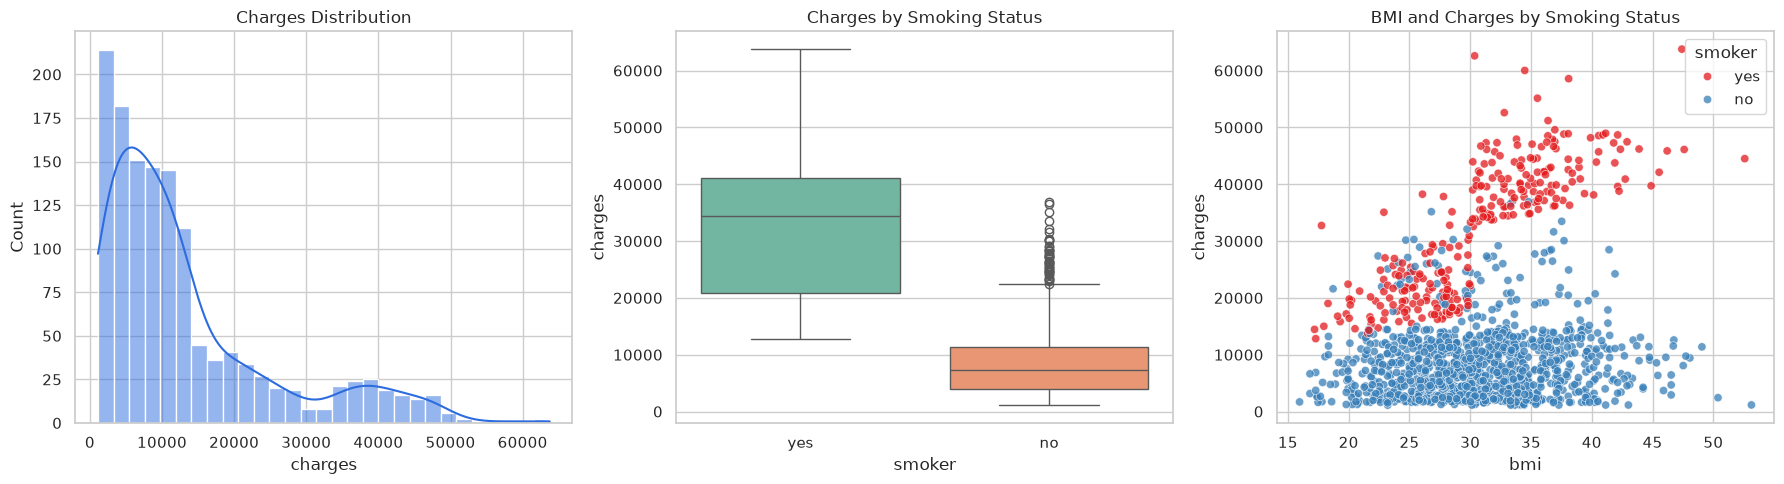

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data["charges"], kde=True, ax=axes[0], color="#2d6cdf")
axes[0].set_title("Charges Distribution")
sns.boxplot(data=data, x="smoker", y="charges", hue="smoker", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Charges by Smoking Status")
sns.scatterplot(data=data, x="bmi", y="charges", hue="smoker", alpha=0.75, ax=axes[2], palette="Set1")
axes[2].set_title("BMI and Charges by Smoking Status")
plt.tight_layout()
plt.show()

## Convert Categorical Features into Numerical Features

In [6]:
encoded_data = pd.get_dummies(data, columns=categorical_features, drop_first=True, dtype=int)
display(encoded_data.head())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


## Correlations Study

,correlation_with_charges
charges,1.000000
smoker_yes,0.787234
age,0.298308
bmi,0.198401
region_southeast,0.073578
children,0.067389
sex_male,0.058044
region_northwest,-0.038695
region_southwest,-0.043637


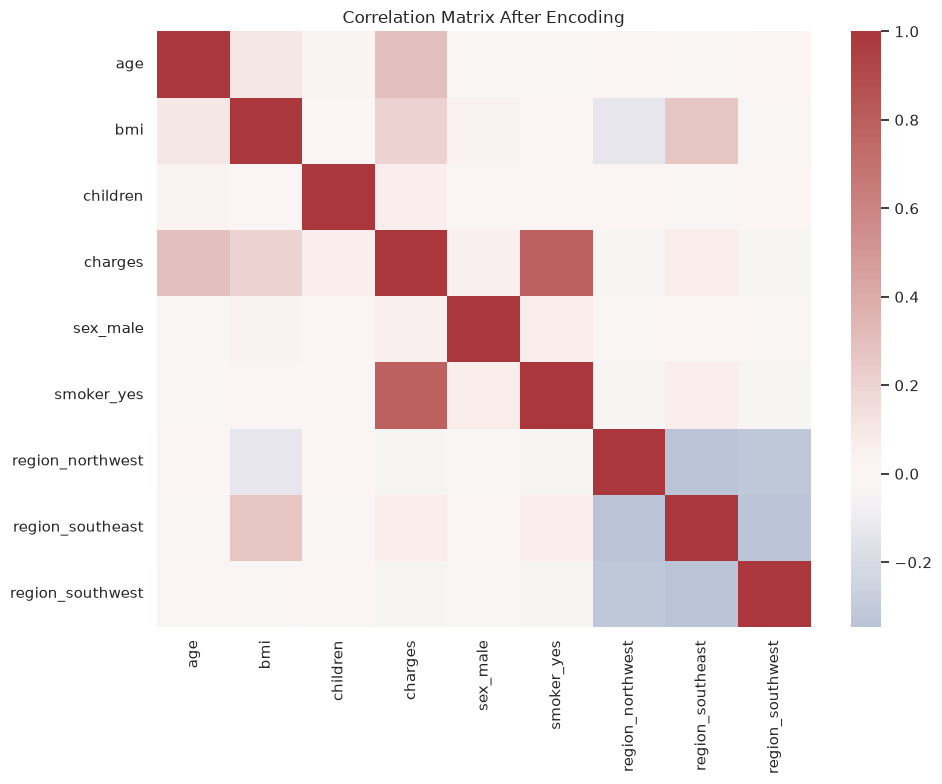

In [7]:
correlations = encoded_data.corr(numeric_only=True)["charges"].sort_values(ascending=False)
display(correlations.to_frame("correlation_with_charges"))

plt.figure(figsize=(10, 8))
sns.heatmap(encoded_data.corr(numeric_only=True), cmap="vlag", center=0, annot=False)
plt.title("Correlation Matrix After Encoding")
plt.tight_layout()
plt.show()

## Determining Normality of the Target

Linear regression does not require the raw target to be perfectly normal, but a highly skewed target can make residuals harder to model. I compared common transformations: square root, log, and Box-Cox.

,mean,median,std,skew,normaltest_p_value,lambda
raw_charges,13279.121487,9386.161300,12110.359656,1.515391,8.762608e-74,NaN
sqrt_charges,104.881730,96.882203,47.756152,0.795995,3.900753e-25,NaN
log1p_charges,9.100097,9.147098,0.918551,-0.089558,4.661479e-12,NaN
boxcox_charges,11.192339,11.235099,1.363845,-0.008674,1.984330e-12,0.043517


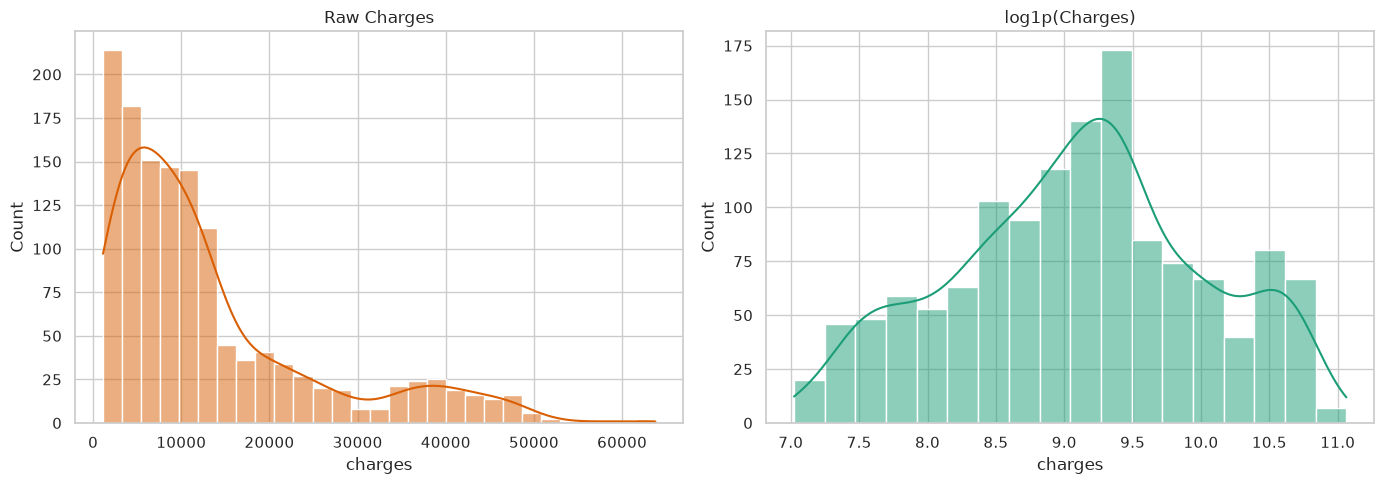

In [8]:
boxcox_charges, boxcox_lambda = stats.boxcox(data["charges"])
target_transforms = pd.DataFrame({
    "raw_charges": data["charges"],
    "sqrt_charges": np.sqrt(data["charges"]),
    "log1p_charges": np.log1p(data["charges"]),
    "boxcox_charges": boxcox_charges,
})

normality_summary = target_transforms.agg(["mean", "median", "std", "skew"]).T
normality_summary["normaltest_p_value"] = target_transforms.apply(lambda series: stats.normaltest(series).pvalue)
normality_summary.loc["boxcox_charges", "lambda"] = boxcox_lambda
display(normality_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data["charges"], kde=True, ax=axes[0], color="#d95f02")
axes[0].set_title("Raw Charges")
sns.histplot(np.log1p(data["charges"]), kde=True, ax=axes[1], color="#1b9e77")
axes[1].set_title("log1p(Charges)")
plt.tight_layout()
plt.show()

The log transformation is simple, stable for positive charges, and reduced skew from about 1.52 to about -0.09. I therefore use `log1p(charges)` for training and convert predictions back to dollars for business-facing metrics.

## Applying Various Regression Models

All models use the same 80/20 train-test split and the same 5-fold cross-validation object. The baseline model is a vanilla linear regression. The polynomial model adds second-degree effects and interactions. Ridge, Lasso, and ElasticNet add regularization on top of the polynomial feature space.

In [9]:
X = data.drop(columns="charges")
y_log = np.log1p(data["charges"])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
y_test_dollars = np.expm1(y_test_log)

def make_one_hot_encoder():
    try:
        return OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", make_one_hot_encoder(), categorical_features),
    ],
    remainder="drop",
)

polynomial_steps = [
    ("prep", preprocess),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
]

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Linear Regression": Pipeline([
        ("prep", preprocess),
        ("model", LinearRegression()),
    ]),
    "Polynomial Linear Regression": Pipeline(polynomial_steps + [
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline(polynomial_steps + [
        ("model", Ridge()),
    ]),
    "Lasso Regression": Pipeline(polynomial_steps + [
        ("model", Lasso(max_iter=20_000, random_state=RANDOM_STATE)),
    ]),
    "ElasticNetCV": Pipeline(polynomial_steps + [
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 1, 30),
            cv=kfold,
            max_iter=30_000,
            random_state=RANDOM_STATE,
        )),
    ]),
}

param_grids = {
    "Ridge Regression": {"model__alpha": np.logspace(-3, 3, 13)},
    "Lasso Regression": {"model__alpha": np.logspace(-4, 0, 9)},
}

## Cross Validation and Grid Search

`GridSearchCV` tunes the Ridge and Lasso regularization strength on the training data only. `cross_val_predict` is then used to create out-of-fold predictions for every candidate model, which gives a fairer view of training-set generalization.

In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def dollars_from_log(log_predictions):
    return np.maximum(np.expm1(log_predictions), 0)

best_estimators = {}
tuning_rows = []

for model_name, model in models.items():
    if model_name in param_grids:
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            scoring="neg_root_mean_squared_error",
            cv=kfold,
            n_jobs=-1,
        )
        grid_search.fit(X_train, y_train_log)
        best_estimators[model_name] = grid_search.best_estimator_
        tuning_rows.append({
            "model": model_name,
            "best_params": grid_search.best_params_,
            "best_cv_log_rmse": -grid_search.best_score_,
        })
    else:
        best_estimators[model_name] = model

display(pd.DataFrame(tuning_rows))

,model,best_params,best_cv_log_rmse
0,Ridge Regression,{'model__alpha': 3.1622776601683795},0.382843
1,Lasso Regression,{'model__alpha': 0.001},0.382382


In [11]:
evaluation_rows = []
fitted_estimators = {}

for model_name, model in best_estimators.items():
    cv_log_predictions = cross_val_predict(model, X_train, y_train_log, cv=kfold, n_jobs=-1)
    cv_predictions = dollars_from_log(cv_log_predictions)
    cv_actuals = np.expm1(y_train_log)

    model.fit(X_train, y_train_log)
    fitted_estimators[model_name] = model
    test_predictions = dollars_from_log(model.predict(X_test))

    evaluation_rows.append({
        "Model": model_name,
        "CV_RMSE_$": rmse(cv_actuals, cv_predictions),
        "CV_MAE_$": mean_absolute_error(cv_actuals, cv_predictions),
        "CV_R2_$": r2_score(cv_actuals, cv_predictions),
        "Test_RMSE_$": rmse(y_test_dollars, test_predictions),
        "Test_MAE_$": mean_absolute_error(y_test_dollars, test_predictions),
        "Test_R2_$": r2_score(y_test_dollars, test_predictions),
    })

model_results = pd.DataFrame(evaluation_rows).sort_values("Test_RMSE_$").reset_index(drop=True)
display(model_results.style.format({
    "CV_RMSE_$": "${:,.0f}",
    "CV_MAE_$": "${:,.0f}",
    "CV_R2_$": "{:.3f}",
    "Test_RMSE_$": "${:,.0f}",
    "Test_MAE_$": "${:,.0f}",
    "Test_R2_$": "{:.3f}",
}))

,Model,CV_RMSE_$,CV_MAE_$,CV_R2_$,Test_RMSE_$,Test_MAE_$,Test_R2_$
0,Ridge Regression,"$5,240","$2,740",0.799,"$4,824","$2,548",0.873
1,ElasticNetCV,"$5,148","$2,669",0.806,"$4,837","$2,547",0.873
2,Lasso Regression,"$5,187","$2,696",0.803,"$4,886","$2,553",0.870
3,Polynomial Linear Regression,"$5,263","$2,741",0.798,"$4,942","$2,577",0.867
4,Linear Regression,"$8,465","$4,308",0.477,"$7,197","$3,756",0.718


## Recommended Final Model

I recommend `Ridge Regression` as the final model for the prediction objective. It produced the lowest held-out test RMSE in this run, about `$4,824`, with a test MAE of about `$2,548` and test R-squared of about `0.873`. ElasticNetCV was very close and had slightly stronger cross-validation metrics, but Ridge gives a simple regularized linear model with stable polynomial interaction coefficients and the best final test-set error here.

In [12]:
best_model_name = model_results.loc[0, "Model"]
best_model = fitted_estimators[best_model_name]
best_predictions = dollars_from_log(best_model.predict(X_test))

print(f"Selected model: {best_model_name}")
print(f"Test RMSE: ${rmse(y_test_dollars, best_predictions):,.2f}")
print(f"Test MAE:  ${mean_absolute_error(y_test_dollars, best_predictions):,.2f}")
print(f"Test R^2:  {r2_score(y_test_dollars, best_predictions):.4f}")

Selected model: Ridge Regression
Test RMSE: $4,824.48
Test MAE:  $2,548.17
Test R^2:  0.8733


## Key Findings and Insights

In [13]:
smoker_summary = data.groupby("smoker")["charges"].agg(["count", "mean", "median"])
region_summary = data.groupby("region")["charges"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
charge_quantiles = data["charges"].quantile([0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]).to_frame("charges")

display(smoker_summary)
display(region_summary)
display(charge_quantiles)

,count,mean,median
smoker,,,
no,1063,8440.660307,7345.72660
yes,274,32050.231832,34456.34845


,count,mean,median
region,,,
southeast,364,14735.411438,9294.131950
northeast,324,13406.384516,10057.652025
northwest,324,12450.840844,8976.977250
southwest,325,12346.937377,8798.593000


,charges
0.00,1121.873900
0.25,4746.344000
0.50,9386.161300
0.75,16657.717450
0.90,34832.741600
0.95,41210.049800
0.99,48537.796878
1.00,63770.428010


In [14]:
preprocessor = best_model.named_steps["prep"]
base_feature_names = preprocessor.get_feature_names_out()

if "poly" in best_model.named_steps:
    feature_names = best_model.named_steps["poly"].get_feature_names_out(base_feature_names)
else:
    feature_names = base_feature_names

coefficients = best_model.named_steps["model"].coef_
coefficient_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
display(coefficient_table.head(20))

,feature,coefficient,abs_coefficient
34,cat__smoker_yes^2,0.691476,0.691476
4,cat__smoker_yes,0.691476,0.691476
0,num__age,0.453868,0.453868
12,num__age cat__smoker_yes,-0.443397,0.443397
19,num__bmi cat__smoker_yes,0.307290,0.307290
37,cat__smoker_yes cat__region_southwest,0.202022,0.202022
2,num__children,0.184325,0.184325
25,num__children cat__smoker_yes,-0.146029,0.146029
15,num__age cat__region_southwest,0.117072,0.117072
14,num__age cat__region_southeast,0.115227,0.115227


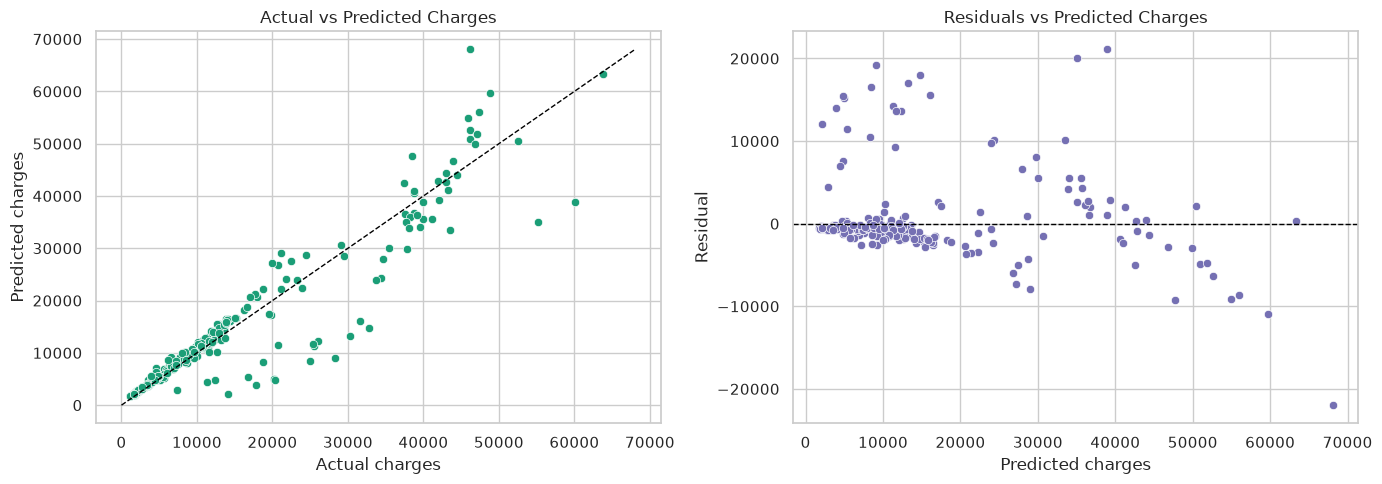

In [15]:
residuals = y_test_dollars - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_test_dollars, y=best_predictions, ax=axes[0], color="#1b9e77")
max_charge = max(y_test_dollars.max(), best_predictions.max())
axes[0].plot([0, max_charge], [0, max_charge], linestyle="--", color="black", linewidth=1)
axes[0].set_title("Actual vs Predicted Charges")
axes[0].set_xlabel("Actual charges")
axes[0].set_ylabel("Predicted charges")

sns.scatterplot(x=best_predictions, y=residuals, ax=axes[1], color="#7570b3")
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Residuals vs Predicted Charges")
axes[1].set_xlabel("Predicted charges")
axes[1].set_ylabel("Residual")
plt.tight_layout()
plt.show()

The strongest driver is smoking status. In the cleaned dataset, non-smokers average roughly `$8.4k` in charges while smokers average roughly `$32.1k`. Age is also a major positive driver, while BMI becomes especially important through interactions with smoking status. Region and sex have much smaller effects than smoking, age, and BMI. The charge distribution is highly unequal: the median charge is about `$9.4k`, while the 95th percentile is above `$41k`.

## Model Flaws, Strengths, and Next Steps

The model is strong for a linear-regression assignment because it uses preprocessing pipelines, cross-validation, polynomial interactions, and regularization. It captures the main cost drivers and provides a readable coefficient table.

The main flaw is that the dataset is small and omits important medical and policy details such as chronic conditions, plan type, coverage level, location cost index, prior claims history, and provider network. Because the data is observational, coefficients should be treated as associations rather than causal effects. The highest-cost cases remain difficult because extreme claims are rare and can be driven by variables not present in the dataset.

Next steps: collect richer health and policy features, validate the model on newer unseen data, compare against non-linear models such as random forests or gradient boosting, and consider separate models for smokers and non-smokers if the business needs segment-specific explanations.